# Exercise 1

We first define all constants given :

In [75]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Params
mu_max = 0.3 # per hour
K_S = 0.8 # g glucose / L
K_I = 100 # g glucose / L
Y_XS = 0.45 # g cells / g glucose
Y_XP = 0.15 # g cells / g product

S0_feed = 80 # g glucose / L (initiation feed)
SP_feed = 80 # g glucose / L (processing feed)

FI = 0.2 # L/h (initiation)
FP = 0.5 # L/h (processing)
FH = 2.5 # L/h (harvesting)

# Phase Durations (Processing Times)
dt_I = 1 # h duration of initiation
dt_P = 5 # h duration of processing (6-1)
dt_H = 1 # h duration of harvesting (7-6)

To account for the uncompetitive substrate inhibition specified, we utilize the Haldane growth model described in Sivakumar et al. (1994). This model incorporates the K_I constant provided :

$$ \mu = \frac{\mu_{max} S}{K_S + S + \frac{S^2}{K_I}} $$

In [76]:
# Kinetics
def mu_net(S):
    """Uncompetitive substrate inhibition Haldane model"""
    mu_net = mu_max * S / (K_S + (S + S**2 / K_I))
    return mu_net

Using the state vector `[N_X, N_S, N_P, V]` we can define all ODEs given in the project's table :

In [77]:
# Concentrations: X=N_X/V, S=N_S/V, P=N_P/V

# ODE right-hand sides (mass balances)
def odes_initiation(t, y):
    N_X, N_S, N_P, V = y
    X = N_X / V
    S = N_S / V
    mu = mu_net(S)
    
    dNX = mu * X * V
    dNS = FI * S0_feed - (mu * X * V / Y_XS)
    dNP = (mu * X * V / Y_XP)
    dV  = FI
    return [dNX, dNS, dNP, dV]

# In this case FI = FP so no change between initiation and processing feed, but we keep separate it's cleaner
def odes_processing(t, y):
    N_X, N_S, N_P, V = y
    X = N_X / V
    S = N_S / V

    mu = mu_net(S)
    dNX = mu * X * V
    dNS = FP * SP_feed - (mu * X * V / Y_XS)
    dNP = (mu * X * V / Y_XP)
    dV  = FP
    return [dNX, dNS, dNP, dV]

def odes_harvesting(t, y):
    N_X, N_S, N_P, V = y
    X = N_X / V
    S = N_S / V
    P = N_P / V

    mu = mu_net(S)
    dNX = -FH * X + mu * X * V
    dNS = -FH * S - (mu * X * V / Y_XS)
    dNP = -FH * P + (mu * X * V / Y_XP)
    dV = -FH
    return [dNX, dNS, dNP, dV]

In [78]:
# Solver helper
def ivp_solver(ode_fun, t_span, y0, n_pts=300):
    sol = solve_ivp(ode_fun, t_span, y0, method="BDF", t_eval=np.linspace(t_span[0], t_span[1], n_pts))
    return sol

# Functions to run initiation or processing + harvesting
def run_initiation(y0, t_start=0.0):
    """Runs the initiation phase"""
    # Integrate from start to start + duration
    sol = ivp_solver(odes_initiation, (t_start, t_start + dt_I), y0)
    return sol

def run_processing_harvest(y0, t_start):
    """Runs processing for dt_P then harvesting for dt_H."""
    # Processing phase
    sol_p = ivp_solver(odes_processing, (t_start, t_start + dt_P), y0)
    
    # Harvesting phase
    y_after_p = sol_p.y[:, -1]
    t_harvest_start = t_start + dt_P
    sol_h = ivp_solver(odes_harvesting, (t_harvest_start, t_harvest_start + dt_H), y_after_p)
    
    return sol_p, sol_h

In [79]:
# Helper to get conc. and time
def extract_conc(sol):
    "Easily extract time and concentrations from the solution"
    N_X, N_S, N_P, V = sol.y
    return sol.t, N_X/V, N_S/V, N_P/V

## Part A : initiation + 1 cycle

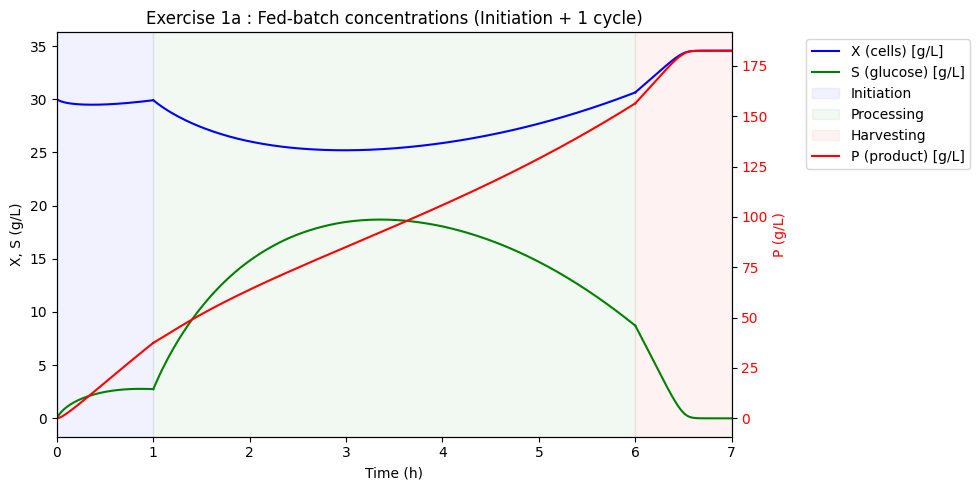

In [80]:
# Initial conditions
V0  = 0.85 # L
X0 = 30 # g/L
N_X0 = X0 * V0 # g
S0 = 0 # g/L
P0 = 0 # g/L
y0 = [N_X0, S0, P0, V0] # initial state vector

# run the full cycle once
sol_i = run_initiation(y0, t_start=0)
sol_p, sol_h = run_processing_harvest(sol_i.y[:, -1], t_start=1)

# Plotting :
process_list = [("Initiation", sol_i), ("Processing", sol_p), ("Harvesting", sol_h)]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

# Only labelling the first iteration, I had many labels otherwise
first = True
for label, sol in process_list:
    t, X, S, P = extract_conc(sol)
    ax1.plot(t, X, "b-", label="X (cells) [g/L]" if first else "")
    ax1.plot(t, S, "g-", label="S (glucose) [g/L]" if first else "")
    ax2.plot(t, P, "r-", label="P (product) [g/L]" if first else "")
    first = False

# Phase shading
ax1.axvspan(0, 1, alpha=0.05, color="blue", label="Initiation")
ax1.axvspan(1, 6, alpha=0.05, color="green", label="Processing")
ax1.axvspan(6, 7, alpha=0.05, color="red", label="Harvesting")

ax1.set_xlabel("Time (h)")
ax1.set_ylabel("X, S (g/L)", color="black")
ax2.set_ylabel("P (g/L)", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Combining all legends and put them outside the plot
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", bbox_to_anchor=(1.1, 1))
ax1.set_title("Exercise 1a : Fed-batch concentrations (Initiation + 1 cycle)")
ax1.set_xlim(0, 7)
plt.tight_layout()
plt.show()


## Part B : initiation + 10 cycles

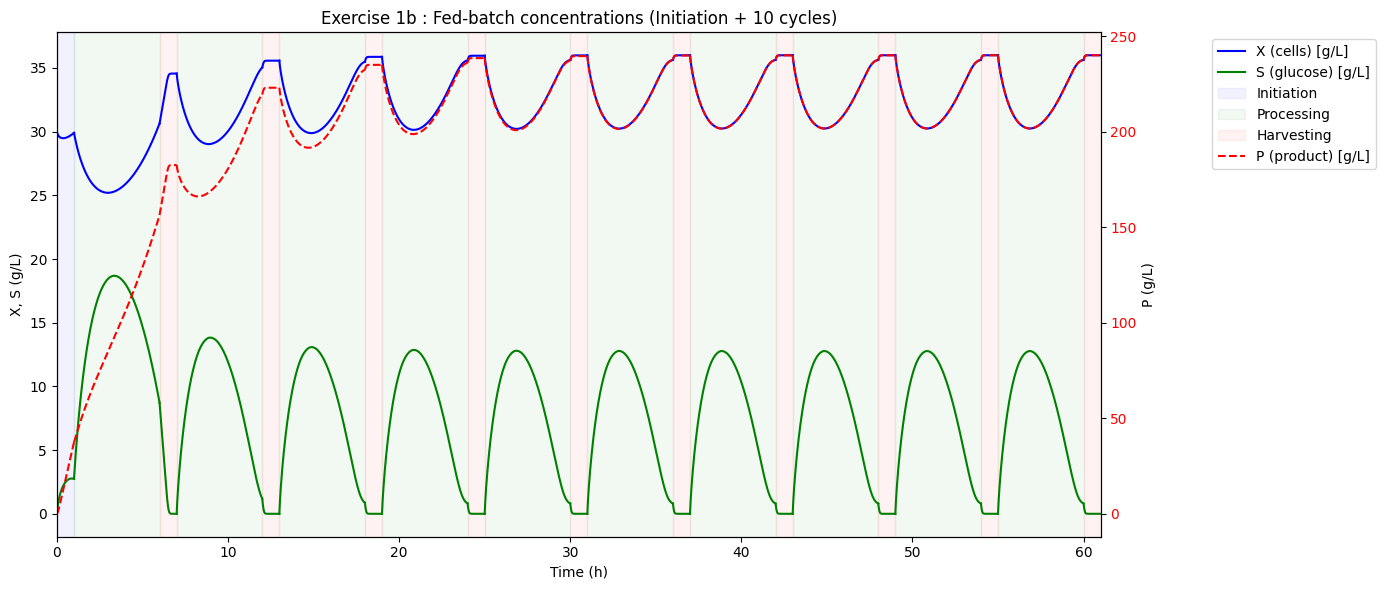

In [ ]:
# initial conditions for the full 10 cycles (same as before)
V0 = 0.85 # L
X0 = 30 # g/L
N_X0 = X0 * V0 # g
S0 = 0 # g/L
P0 = 0 # g/L
y0 = [N_X0, S0, P0, V0] # initial state vector

n_cycles = 10

all_sols = [] # list of (phase_label, sol)
t_offset = 0

# Initiation
sol_i = run_initiation(y0, t_start=t_offset)
all_sols.append(("initiation", sol_i))
t_offset += dt_I

# then 10 cycles of processing + harvesting
for cycle in range(n_cycles):
    y_start = all_sols[-1][1].y[:, -1]
    sol_p, sol_h = run_processing_harvest(y_start, t_start=t_offset)
    all_sols.append(("processing", sol_p))
    all_sols.append(("harvesting", sol_h))
    t_offset += dt_P + dt_H


# Plotting
fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# Only labelling the first iteration, many labels otherwise    
first = True
for _, sol in all_sols:
    t, X, S, P = extract_conc(sol)
    ax1.plot(t, X, "b-", label="X (cells) [g/L]" if first else "")
    ax1.plot(t, S, "g-", label="S (glucose) [g/L]" if first else "")
    ax2.plot(t, P, "r--", label="P (product) [g/L]" if first else "")
    first = False

# Phase shading
t_off = 0
# Initiation
ax1.axvspan(t_off, t_off+1, alpha=0.05, color="blue", label="Initiation")
t_off += 1
# 10 cycles of processing + harvesting. Again label only the first pass to avoid having many legends
for _ in range(10):
    ax1.axvspan(t_off, t_off+dt_P, alpha=0.05, color="green", label="Processing" if t_off == 1 else "")
    ax1.axvspan(t_off+dt_P, t_off+dt_P+dt_H, alpha=0.05, color="red", label="Harvesting" if t_off == 1 else "")
    t_off += dt_P + dt_H


ax1.set_xlabel("Time (h)")
ax1.set_ylabel("X, S (g/L)")
ax2.set_ylabel("P (g/L)")
ax2.tick_params(axis="y", labelcolor="red")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", bbox_to_anchor=(1.1, 1))
ax1.set_title("Exercise 1b : Fed-batch concentrations (Initiation + 10 cycles)")
ax1.set_xlim(0, t_off)
plt.tight_layout()
plt.show()


For the production rate we use :

Production rate = (P_produced - P_harvested) / cycle_time

But at steady-state P_producer = P_harvested so we should get approx. 0.

In [82]:
# Production rate calculation : Production rate = (P_produced - P_harvested) / cycle_time

# last processing and harvesting solutions for the 10th cycle
idx_last_proc = 1 + (n_cycles - 1) * 2
idx_last_harv = idx_last_proc + 1

sol_p = all_sols[idx_last_proc][1]
sol_h = all_sols[idx_last_harv][1]

# Grams of P at start of 10th processing
P_start_mass = sol_p.y[2, 0]

# Grams of P at end of 10th processing (before harvest)
P_after_proc = sol_p.y[2, -1]

# Grams of P at end of harvest
P_after_harv = sol_h.y[2, -1]

# P produced during cycle
P_produced = P_after_proc - P_start_mass

# P harvested = P_after_proc - P_after_harv (what left the reactor)
P_harvested = P_after_proc - P_after_harv

cycle_time = dt_P + dt_H

# Production and harvesting quantities over the cycle time
prod_rate_produced = P_produced / cycle_time
prod_rate_harvested = P_harvested / cycle_time

# Production rate as asked in the question: (P produced - P harvested) / cycle_time
prod_rate_net = (P_produced - P_harvested) / cycle_time


print(f"P at start of 10th processing : {P_start_mass:.4f} g")
print(f"P at end of 10th processing : {P_after_proc:.4f} g")
print(f"P at end of 10th harvesting : {P_after_harv:.4f} g")
print(f"P produced in cycle : {P_produced:.4f} g")
print(f"P harvested in cycle : {P_harvested:.4f} g")
print(f"Cycle time : {cycle_time:.2f} h")
print(f"Production rate (1) (produced/time): {prod_rate_produced:.4f} g/h")
print(f"Harvest rate (harvested/time): {prod_rate_harvested:.4f} g/h")
print(f"Production rate (2) ((produced - harvested)/cycle time): {prod_rate_net:.4f} g/h")

P at start of 10th processing : 251.9965 g
P at end of 10th processing : 843.4520 g
P at end of 10th harvesting : 251.9990 g
P produced in cycle : 591.4555 g
P harvested in cycle : 591.4530 g
Cycle time : 6.00 h
Production rate (1) (produced/time): 98.5759 g/h
Harvest rate (harvested/time): 98.5755 g/h
Production rate (2) ((produced - harvested)/cycle time): 0.0004 g/h
